In [107]:

using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Plots.PlotMeasures  # Required for the 'mm' unit
using Statistics
using LinearAlgebra
using TimeZones

using Optim
using Zygote
using FiniteDiff
using ForwardDiff

using MAT

In [108]:
# input parameters
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
number_of_panels = 1
installation_azimuth = 180.0
installation_tilt = latitude

# PV module
module_name = "Kyocera Solar KD135GX-LP [2008 (E)]" 
pv_module = read_solar_module(module_name)

# weather data parameters
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)

# load in WEC response
data = matread("pioneer_6dof_response_wave1.mat")
time = vec(data["time"])
WEC_response = data["WEC_response"];

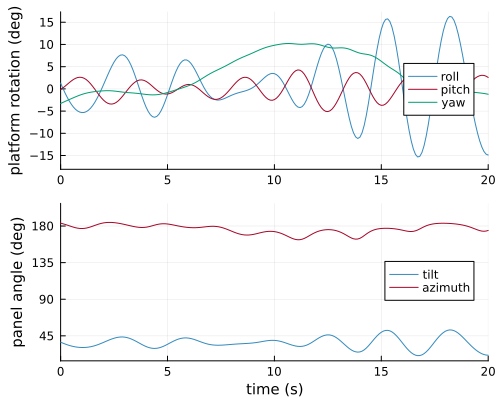

In [109]:
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, installation_tilt, installation_azimuth)

t = time                      # length N
x = WEC_response[:,1]; y = WEC_response[:,2]; z = WEC_response[:,3]
roll  = WEC_response[:,4]
pitch = WEC_response[:,5]
yaw   = WEC_response[:,6]

start_time = 1280
end_time = 1300

plot_colors = ["#348ABD", "#A60628", "#009E73", "#7A68A6", "#D55E00", "#CC79A7"]

# 2) Rotational motions
p2 = plot(t.-start_time, roll*180/pi,  label="roll", ylabel="platform rotation (deg)",xlims=(0, end_time-start_time), palette=plot_colors)
plot!(p2, t.-start_time, pitch*180/pi, label="pitch")
plot!(p2, t.-start_time, yaw*180/pi,   label="yaw")

# 3) Panel angles
p3 = plot(t.-start_time, panel_tilt, label="tilt", xlabel="time (s)", ylabel="panel angle (deg)", xlims=(0, end_time-start_time),yticks=0:45:225, palette=plot_colors)
plot!(p3, t.-start_time, panel_azimuth,   label="azimuth")

p = plot(p2, p3, layout=(2,1), legend=:right, size = (500, 400), guidefontsize = 10, bottom_margin = -1mm)
display(p)
#savefig(p, "figures/tilt_azimuth.png")

In [110]:
days = [
    (1, 15),
    (4, 15),
    (7, 15),
    (10, 15),
]

n_days = length(days)
n_hours = 24

example_tilt = 0.0
example_azimuth = 180.0

weather_data_all = Vector{Any}(undef, n_days)
solar_position_all = Vector{Any}(undef, n_days)
total_irradiance_all = Vector{Any}(undef, n_days)
cell_temp_all = Vector{Any}(undef, n_days)
cell_temp_orig_all = Vector{Any}(undef, n_days)
albedo_all = Matrix{Float64}(undef, n_days, n_hours)

for day_ind in eachindex(days)
    start_monthday = days[day_ind]
    end_monthday = days[day_ind]

    weather_data = get_meteorological_data_nsrdb(
        latitude,
        longitude,
        api_key,
        email,
        start_monthday,
        end_monthday,
        false,
    )

    solar_position = get_solar_position(
        latitude,
        longitude,
        altitude,
        weather_data,
    )

    weather_data_all[day_ind] = weather_data
    solar_position_all[day_ind] = solar_position

    # get albedo over the course of the day
    albedo_all[day_ind,:] = get_ocean_surface_albedo(weather_data, solar_position)

    total_irradiance = get_total_irradiance(example_tilt, example_azimuth, weather_data, solar_position, albedo_all[day_ind,:]) 
    total_irradiance_all[day_ind] = total_irradiance
    cell_temp_orig = sapm_cell_temperature(total_irradiance, weather_data)
    cell_temp_orig_all[day_ind] = cell_temp_orig
end

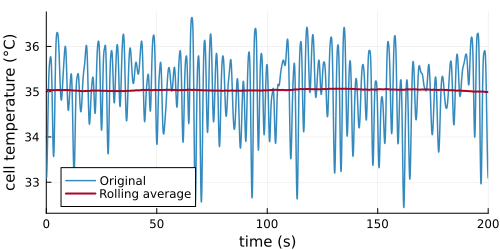

In [111]:
# select a single season/hour to demonstrate the rolling average cell temp
season_ind = 1
hour_ind = 12

total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data_all[season_ind][hour_ind], solar_position_all[season_ind][hour_ind], albedo_all[season_ind,hour_ind], time) 
cell_temp_orig = sapm_cell_temperature(total_irradiance, weather_data_all[season_ind][hour_ind])
cell_temp_avg = rolling_average_sapm_cell_temperature(total_irradiance, weather_data_all[season_ind][hour_ind])

start_time = 1100
end_time = 1300

p = plot(time.-start_time, getfield.(cell_temp_orig,:cell_temperature), xlabel="time (s)", ylabel="cell temperature (°C)", xlims=[0, end_time-start_time],label="Original", linewidth=1.5, size = (500, 250), guidefontsize = 10, palette=plot_colors)
plot!(p, time.-start_time, getfield.(cell_temp_avg,:cell_temperature),label="Rolling average", linewidth=2)

display(p)
#savefig(p, "figures/cell_temp_rolling.png")

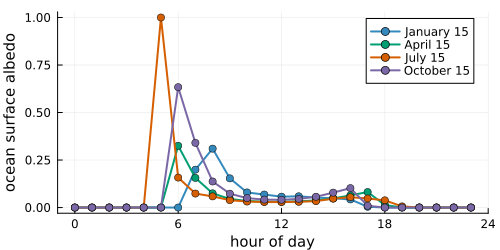

In [112]:
labels = ["January 15", "April 15", "July 15", "October 15"]
season_colors = [
    "#348ABD",  # January - blue
    "#009E73",  # April - green
    "#D55E00",  # July - orange
    "#7A68A6",  # October - purple
]
hours = 0:23

p = plot(
    xlabel = "hour of day",
    ylabel = "ocean surface albedo",
    legend = :best,
    xticks = 0:6:24,
    xlims = (-1, 24),
    guidefontsize = 10,
)

for day_ind in eachindex(labels)
    plot!(
        p,
        hours,
        albedo_all[day_ind, :],
        label = labels[day_ind],
        linewidth = 2,
        marker = :circle,
        size=(500, 250), 
        palette = season_colors
    )
end

display(p)

#savefig(p, "figures/seasonal_albedo.png")

In [113]:
function world_point_to_panel(
    q_world::Tuple{<:Real,<:Real,<:Real},
    panel_center_world::Tuple{<:Real,<:Real,<:Real},
    panel_tilt_deg::Real,
    panel_azimuth_deg::Real,
)
    β = deg2rad(panel_tilt_deg)
    γ = deg2rad(panel_azimuth_deg)

    xhat = (cos(γ), -sin(γ), zero(γ))
    yhat = (cos(β) * sin(γ), cos(β) * cos(γ), -sin(β))
    zhat = (sin(β) * sin(γ), sin(β) * cos(γ), cos(β))

    dq = (
        q_world[1] - panel_center_world[1],
        q_world[2] - panel_center_world[2],
        q_world[3] - panel_center_world[3],
    )

    qx = dot(dq, xhat)
    qy = dot(dq, yhat)
    qz = dot(dq, zhat)

    return (qx, qy, qz)
end

function world_box_to_panel_box(
    xmin_w::Real,
    xmax_w::Real,
    ymin_w::Real,
    ymax_w::Real,
    zmin_w::Real,
    zmax_w::Real,
    panel_center_world::Tuple{<:Real,<:Real,<:Real},
    panel_tilt_deg::Real,
    panel_azimuth_deg::Real,
)
    corners_world = [
        (x, y, z)
        for x in (xmin_w, xmax_w)
        for y in (ymin_w, ymax_w)
        for z in (zmin_w, zmax_w)
    ]

    corners_panel = [
        world_point_to_panel(
            corner,
            panel_center_world,
            panel_tilt_deg,
            panel_azimuth_deg,
        )
        for corner in corners_world
    ]

    xs = [p[1] for p in corners_panel]
    ys = [p[2] for p in corners_panel]
    zs = [p[3] for p in corners_panel]

    return BoxObstacle(
        minimum(xs),
        maximum(xs),
        minimum(ys),
        maximum(ys),
        minimum(zs),
        maximum(zs),
    )
end

world_box_to_panel_box (generic function with 1 method)

In [114]:
# installation characteristics
panel = Panel(1.5, 0.668) # panel dimensnions in meters (Kyocera Solar KD140)
example_panel_center_world = (0.0, 0.0, 0.8)  # panel center location on buoy/platform
n_cells_per_column = 9

obstacle = world_box_to_panel_box(
    -2.0, 2.0,   # obstacle x bounds in platform/world frame
    -2.0, 2.0,   # obstacle y bounds in platform/world frame
    2.0, 4.0,   # obstacle z bounds in platform/world frame
    example_panel_center_world,
    example_tilt,
    example_azimuth,
)

# example if panel was placed directly below the obstacle at no tilt

shaded_fraction = zeros(length(days), length(solar_position_all[1]))
power_norm = zeros(length(days), length(solar_position_all[1]))

for day_ind in eachindex(days)
    for hour_ind in eachindex(solar_position_all[day_ind])
        shaded_fraction[day_ind,hour_ind] = get_shaded_fraction(solar_position_all[day_ind][hour_ind], example_tilt, example_azimuth, panel, obstacle, nx=10, ny=10)
        power_norm[day_ind,hour_ind] = get_power_norm(total_irradiance_all[day_ind][hour_ind], shaded_fraction[day_ind,hour_ind], n_cells_per_column)
    end
end

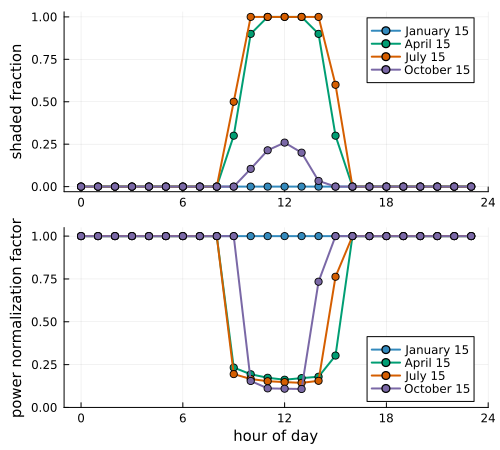

In [115]:
labels = ["January 15", "April 15", "July 15", "October 15"]
hours = 0:23

p1 = plot(
    ylabel = "shaded fraction",
    legend = :best,
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

for day_ind in eachindex(labels)
    plot!(
        p1,
        hours,
        shaded_fraction[day_ind, :],
        label = labels[day_ind],
        linewidth = 2,
        marker = :circle,
    )
end

p2 = plot(
    xlabel = "hour of day",
    ylabel = "power normalization factor",
    legend = :best,
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

for day_ind in eachindex(labels)
    plot!(
        p2,
        hours,
        power_norm[day_ind, :],
        label = labels[day_ind],
        linewidth = 2,
        marker = :circle,
        ylims=(0, 1.05)
    )
end

p = plot(p1, p2, layout = (2, 1), size=(500, 450), guidefontsize = 10,bottom_margin=-1mm)
display(p)
#savefig(p, "figures/seasonal_shading.png")

In [116]:
function average_final_field(dc_components, field::Symbol, final_minutes = 20)
    t_end = dc_components[end].time
    t_start = t_end - Minute(final_minutes)

    values_final = [
        getfield(dc, field) for dc in dc_components
        if dc.time >= t_start
    ]

    isempty(values_final) && error("No values found in final time window.")

    return mean(values_final)
end

# create function that support installation tilt and installation direction inputs 
# installation direction is the angle around the buoy where the panel installed with 0 being on the north side
function dc_power_seasons(latitude, longitude, altitude, 
                        installation_tilt, installation_direction, weather_data_all, solar_position_all, 
                        pv_module, WEC_response, n_cells_per_column, sim_time; return_details = false)

    # installation characteristics
    panel = Panel(1.5, 0.668) # panel dimensnions in meters (Kyocera Solar KD140)
    panel_x = 2.5*sind(installation_direction)
    panel_y = 2.5*cosd(installation_direction)
    example_panel_center_world = (panel_x, panel_y, 0.8)  # panel center location on buoy/platform

    installation_azimuth = installation_direction

    n_days = length(weather_data_all)
    n_hours = length(weather_data_all[1])
    T = promote_type(typeof(installation_tilt), typeof(installation_direction), Float64)
    
    avg_power = Matrix{T}(undef, n_days, n_hours)
    avg_total_irradiance = Matrix{T}(undef, n_days, n_hours)
    avg_effective_irradiance = Matrix{T}(undef, n_days, n_hours)

    for day_ind in 1:length(weather_data_all)
        weather_data_day = weather_data_all[day_ind]
        solar_position_day = solar_position_all[day_ind]
        for hour_ind in 1:length(weather_data_day)
            weather_data = weather_data_day[hour_ind]
            solar_position = solar_position_day[hour_ind]

            albedo = get_ocean_surface_albedo(weather_data, solar_position)
            instantaneous_tilt, instantaneous_azimuth = panel_tilt_azimuth(WEC_response, installation_tilt, installation_azimuth)

            total_irradiance = get_total_irradiance(instantaneous_tilt, instantaneous_azimuth, weather_data, solar_position, albedo, sim_time) 
            cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)
            effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, solar_position, instantaneous_tilt, instantaneous_azimuth, altitude)

            shaded_fraction = [
                get_shaded_fraction(
                    solar_position,
                    instantaneous_tilt[i],
                    instantaneous_azimuth[i],
                    panel,
                    world_box_to_panel_box(
                        -2.0, 2.0,
                        -2.0, 2.0,
                        2.0, 4.0,
                        example_panel_center_world,
                        instantaneous_tilt[i],
                        instantaneous_azimuth[i],
                    );
                    nx = 6,
                    ny = 6,
                )
                for i in eachindex(instantaneous_tilt)
            ]
            power_norm = get_power_norm(total_irradiance, shaded_fraction, n_cells_per_column)

            dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)
            
            avg_total_irradiance[day_ind, hour_ind] = average_final_field(total_irradiance, :poa_global, 20)
            avg_effective_irradiance[day_ind, hour_ind] = average_final_field(effective_irradiance, :effective_irradiance, 20)
            # for each hour, average the power over the last 20 minutes
            avg_power[day_ind, hour_ind] = average_final_field(dc_components_shaded, :p_mp, 20)
        end
    end
    if return_details
        return (
            avg_power = avg_power,
            avg_total_irradiance = avg_total_irradiance,
            avg_effective_irradiance = avg_effective_irradiance
        )
    else
        return avg_power
    end
end

dc_power_seasons (generic function with 1 method)

In [117]:

# select subset to run quicker optimization
weather_data_subset = [weather_data_all[d][12:13] for d in 1:2]
solar_position_subset = [solar_position_all[d][12:13] for d in 1:2]
weather_data_subset = weather_data_all
solar_position_subset = solar_position_all;

In [118]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_direction, weather_data_all, solar_position_all, 
                        pv_module, WEC_response, n_cells_per_column, sim_time)

    avg_power = mean(dc_power_seasons(latitude, longitude, altitude, 
                        installation_tilt, installation_direction, weather_data_all, solar_position_all, 
                        pv_module, WEC_response, n_cells_per_column, sim_time))
    return -avg_power
end

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data_subset, solar_position_subset, pv_module, WEC_response, n_cells_per_column, time)
println("Mean power for installation tilt: ", -check_mean_power)

Mean power for installation tilt: 28.250676137348275


In [119]:

# optimize installation tilt and azimuth
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], orientation[2], weather_data_subset, solar_position_subset, pv_module, WEC_response, n_cells_per_column, time)

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

surface_tilt = latitude
x0 = [surface_tilt, 180.0]
lower = [0.0, 0.0]
upper = [90.0, 360.0]

res = optimize(mean_power, g!, lower, upper, x0, Fminbox(BFGS()),
                Optim.Options(show_trace = true, show_every = 1, iterations = 100),)

println("Optimal installation tilt: ", res.minimizer[1])
println("Optimal installation azimuth: ", res.minimizer[2])
println("Maximum mean power: ", -res.minimum)

Fminbox
-------
Initial mu = 0.00102784

Fminbox iteration 1
-------------------
Calling inner optimizer with mu = 0.00102784

(numbers below include barrier contribution)
Iter     Function value   Gradient norm 
     0    -2.826913e+01     3.379136e-02
 * time: 0.04699993133544922
     1    -2.842197e+01     2.238345e-02
 * time: 550.0940001010895
     2    -2.842299e+01     2.789959e-02
 * time: 731.0160000324249
     3    -2.844716e+01     1.996484e-03
 * time: 1187.305999994278
     4    -2.845014e+01     5.270134e-03
 * time: 1465.7239999771118
     5    -2.845024e+01     4.834707e-03
 * time: 1924.279000043869
     6    -2.845037e+01     7.726930e-04
 * time: 2111.4030001163483
     7    -2.845043e+01     4.351157e-04
 * time: 2386.914999961853
     8    -2.845044e+01     3.659921e-04
 * time: 2572.7269999980927
     9    -2.845068e+01     2.406812e-03
 * time: 3030.5670001506805
    10    -2.845069e+01     1.695716e-03
 * time: 3224.638999938965
    11    -2.845078e+01     3.937

In [120]:
tilt_range = 0.0:5.0:90.0
direction_range = 0.0:10.0:360.0

power_grid = [
    -objective(
        latitude, longitude, altitude, tilt, direction, weather_data_subset, 
        solar_position_subset, pv_module, WEC_response, n_cells_per_column, time
        )
    for tilt in tilt_range, direction in direction_range
]


19×37 Matrix{Float64}:
  9.47782  10.0051   10.3763   …  9.51208  9.4486   9.37713   9.47782
  8.99712   9.40333   9.81263     8.87706  8.78845  8.76373   8.99712
  8.45575   8.75016   9.20739     8.20709  8.07287  8.15787   8.45575
  7.91554   8.20239   8.61921     7.44629  7.34596  7.53059   7.91554
  7.6623    7.91166   8.12348     6.78855  6.77081  7.11314   7.6623
  7.99544   8.07457   8.0807   …  6.42148  6.60716  7.23661   7.99544
  8.85168   8.88927   8.71211     6.60967  7.04961  7.90353   8.85168
  9.65067   9.86098   9.78575     7.69999  7.95342  8.67628   9.65067
 10.0918   10.4135   10.5331      9.06622  8.86976  9.30627  10.0918
  9.8798   10.3244   10.8596      9.86857  9.32003  9.39337   9.8798
  8.86649   9.45486  10.3587   …  9.38725  8.74747  8.58538   8.86649
  7.52209   8.1721    9.21787     8.20236  7.51839  7.28203   7.52209
  6.22282   6.88715   7.95856     7.02549  6.29691  6.01341   6.22282
  5.11712   5.77386   6.84931     6.02423  5.27744  4.95113   5.11712


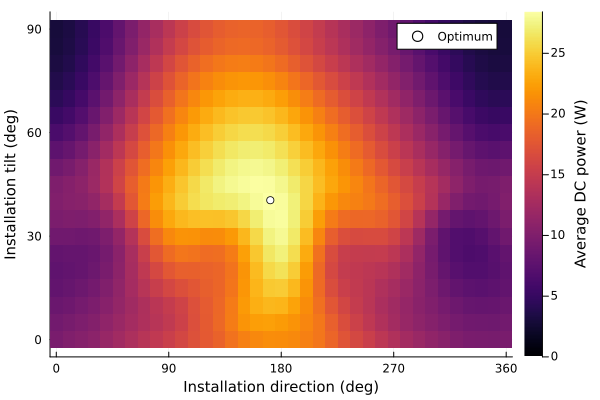

"c:\\Users\\jtgrasb\\Documents\\GitHub\\PVlib.jl\\examples\\figures\\opt_res.png"

In [ ]:
p1 = heatmap(
    direction_range,
    tilt_range,
    power_grid,
    xlabel="Installation direction (deg)",
    ylabel="Installation tilt (deg)",
    colorbar_title="Average DC power (W)",
    legend=:topright,
    clims = (0, maximum(power_grid)),
    xticks = 0:90:360,
    xlims = (-5, 365),
    yticks = 0:30:90,
    ylims = (-5, 95),
    guidefontsize = 10,
)

scatter!(p1, [res.minimizer[2]], [res.minimizer[1]], color=:white, markerstrokecolor=:black, label="Optimum")

display(p1)

#savefig(p1, "figures/opt_res.png")

In [122]:
opt_tilt = res.minimizer[1]
opt_direction = res.minimizer[2]

#opt_tilt = 40.4
#opt_direction = 171.3

results = dc_power_seasons(
    latitude,
    longitude,
    altitude,
    opt_tilt,
    opt_direction,
    weather_data_all,
    solar_position_all,
    pv_module,
    WEC_response,
    n_cells_per_column,
    time;
    return_details = true,
);

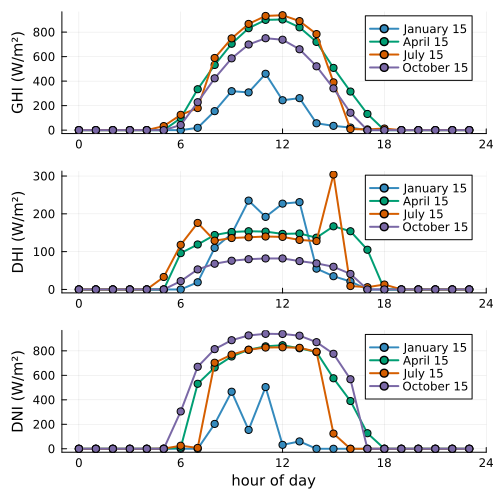

In [123]:
labels = ["January 15", "April 15", "July 15", "October 15"]
hours = 0:23

n_days = length(weather_data_all)
n_hours = length(weather_data_all[1])

ghi = Matrix{Float64}(undef, n_days, n_hours)
dhi = Matrix{Float64}(undef, n_days, n_hours)
dni = Matrix{Float64}(undef, n_days, n_hours)

for day_ind in 1:n_days
    for hour_ind in 1:length(weather_data_all[day_ind])
        ghi[day_ind, hour_ind] = weather_data_all[day_ind][hour_ind].ghi
        dhi[day_ind, hour_ind] = weather_data_all[day_ind][hour_ind].dhi
        dni[day_ind, hour_ind] = weather_data_all[day_ind][hour_ind].dni
    end
end

p1 = plot(
    hours,
    ghi',
    ylabel = "GHI (W/m²)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    #ylabel = "Global horizontal irradiance",
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

p2 = plot(
    hours,
    dhi',
    ylabel = "DHI (W/m²)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    #ylabel = "Diffuse horizontal irradiance",
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

p3 = plot(
    hours,
    dni',
    xlabel = "hour of day",
    ylabel = "DNI (W/m²)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    #ylabel = "Direct normal irradiance",
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

plot(p1, p2, p3, layout = (3, 1), size = (500, 500), guidefontsize = 10, bottom_margin=-1mm)

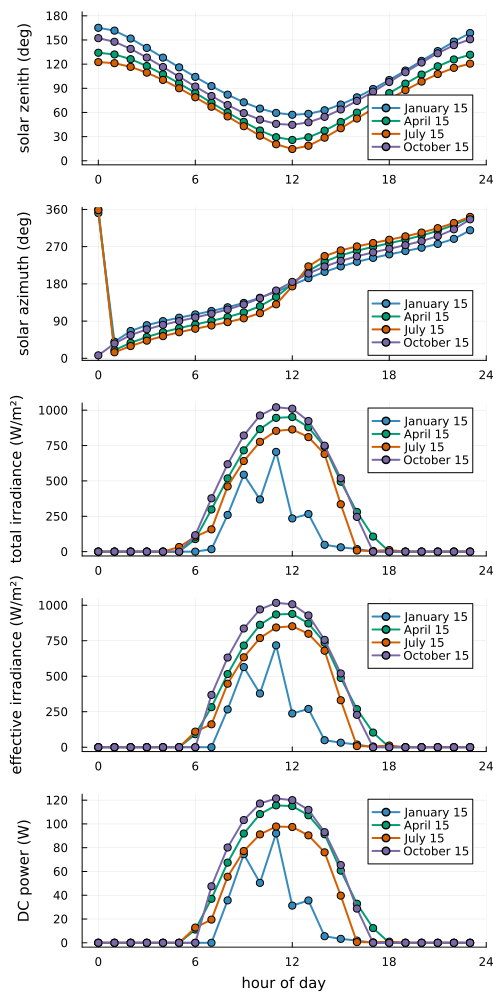

"c:\\Users\\jtgrasb\\Documents\\GitHub\\PVlib.jl\\examples\\figures\\seasonal_opt.png"

In [ ]:
labels = ["January 15", "April 15", "July 15", "October 15"]
hours = 0:23

solar_zenith = Matrix{Float64}(undef, n_days, n_hours)
solar_azimuth = Matrix{Float64}(undef, n_days, n_hours)

for day_ind in 1:n_days
    for hour_ind in 1:length(solar_position_all[day_ind])
        solar_zenith[day_ind, hour_ind] = solar_position_all[day_ind][hour_ind].zenith
        solar_azimuth[day_ind, hour_ind] = solar_position_all[day_ind][hour_ind].azimuth
    end
end

p1 = plot(
    hours,
    solar_zenith',
    ylabel = "solar zenith (deg)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    xticks = 0:6:24,
    xlims = (-1, 24),
    yticks = 0:30:180,
    ylims = (-5, 185),
    palette = season_colors
)

p2 = plot(
    hours,
    solar_azimuth',
    ylabel = "solar azimuth (deg)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    xticks = 0:6:24,
    xlims = (-1, 24),
    yticks = 0:90:360,
    ylims = (-5, 365),
    palette = season_colors
)

n_days = length(solar_position_all)
n_hours = length(solar_position_all[1])

p3 = plot(
    hours,
    results.avg_total_irradiance',
    ylabel = "total irradiance (W/m²)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

p4 = plot(
    hours,
    results.avg_effective_irradiance',
    ylabel = "effective irradiance (W/m²)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

p5 = plot(
    hours,
    results.avg_power',
    xlabel = "hour of day",
    ylabel = "DC power (W)",
    label = reshape(labels, 1, :),
    linewidth = 2,
    marker = :circle,
    xticks = 0:6:24,
    xlims = (-1, 24),
    palette = season_colors
)

p = plot(p1, p2, p3, p4, p5, layout = (5, 1), size=(500, 1000), left_margin = 8mm, guidefontsize = 10, bottom_margin=-1mm)
display(p)

#savefig(p, "figures/seasonal_opt.png")